<a href="https://colab.research.google.com/github/Karamoko27/InOutVision/blob/main/InOutVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <b> ELG 5255: Applied Machine Learning <br>University of Ottawa <br>FALL 2025 </b>
## <center> <b> <u> Project: InOutVision </u> </b> </center>

#### - Karamoko Soumare <br>- Elame Olame Mugabo <br>- Stanley Vianney

## <b> 1) <u> The first part of our Project is to use a pretrain Facenet model for our own dataset</u>:

#### <b> INSTALLING AND IMPORTING LIBRAIRIES:

In [ ]:
!pip install facenet-pytorch retina-face opencv-python scikit-learn matplotlib

In [ ]:
!pip install ultralytics

In [ ]:
import torch
import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from PIL import Image
from facenet_pytorch import InceptionResnetV1
from retinaface import RetinaFace
from ultralytics import YOLO
import torchvision.transforms as transforms
from collections import defaultdict
import matplotlib.pyplot as plt


In [ ]:
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

#### <b> IMPORTING AND DOWNLOADING OUR DATASET FROM GITHUB:

In [ ]:
!rm -rf InOutVision
!git clone --depth 1 --filter=blob:none --sparse https://github.com/Karamoko27/InOutVision.git
%cd InOutVision
!git sparse-checkout set Dataset Pictest VideoTest
%cd ..

Cloning into 'InOutVision'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 10 (delta 0), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), done.
remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 95.89 KiB | 4.00 MiB/s, done.
/content/InOutVision
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 28 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 66.24 MiB | 27.85 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (30/30), done.
/content


In [ ]:
github_url = "https://github.com/Karamoko27/InOutVision/tree/main/Dataset"

#### <b> LOADING FACENET AND CREATING FUNCTIONS FOR USAGE:

In [ ]:
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
model = resnet
print("FaceNet Model Loaded")

FaceNet Model Loaded


In [ ]:
#detect face
def detect_face(img):
    obj = RetinaFace.detect_faces(img)

    # If no faces detected
    if not isinstance(obj, dict) or len(obj) == 0:
        return None   # <- safe return

    # Extract the first face
    key = next(iter(obj))
    x1, y1, x2, y2 = obj[key]['facial_area']
    return img[y1:y2, x1:x2]


In [ ]:
# processing face image
def preprocess(img):
    """Resize + normalize for FaceNet"""
    img = cv2.resize(img, (160, 160))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    return torch.tensor(img).unsqueeze(0).to(device)

In [ ]:
# face embedding
def embed_face(img):
    """Return 512-D embedding"""
    face = detect_face(img)
    if face is None:
        return None
    tensor = preprocess(face)
    with torch.no_grad():
        return resnet(tensor).cpu().numpy()[0]

#### <b> DATASET EMBEDDINGS:

In [ ]:
dataset_path = "InOutVision/Dataset"
embeddings = []
labels = []

In [ ]:
embeddings_dict = {}


for person in os.listdir(dataset_path):
    person_dir = os.path.join(dataset_path, person)
    if not os.path.isdir(person_dir):
        continue

    print("Encoding:", person)

    for img_name in os.listdir(person_dir):
        img_path = os.path.join(person_dir, img_name)

        img = cv2.imread(img_path)
        face = detect_face(img)  # Your function to return cropped face
        if face is None:
            print("  - No face in", img_name)
            continue

        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_img = Image.fromarray(face_rgb)
        face_tensor = transform(face_img).unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model(face_tensor).cpu().numpy()[0]

        # Store embeddings in a list per person
        if person not in embeddings_dict:
            embeddings_dict[person] = []
        embeddings_dict[person].append(emb)


Encoding: Stanley
Encoding: Karamoko
Encoding: Elame


In [ ]:
print(embeddings_dict.keys())

dict_keys(['Stanley', 'Karamoko', 'Elame'])


#### <b> TRAINING SVM CLASSIFIER:

In [ ]:
X = []
y = []

for person, emb_list in embeddings_dict.items():
    for emb in emb_list:
        X.append(emb)  # Each embedding is a row
        y.append(person)

X = np.array(X)  # Shape: (num_samples, embedding_size)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

clf = SVC(kernel='linear', probability=True)
clf.fit(X, y_encoded)

print("Training completed.")

Training completed.


In [ ]:
X

array([[  0.0055931,  0.00040871,   -0.045711, ...,  -0.0054006,    -0.05621,   -0.091667],
       [ -0.0043413,  -0.0031183,   -0.046246, ..., -0.00038937,   -0.045299,   -0.074335],
       [  -0.057186,   -0.044658,   -0.057068, ...,   0.0095053,   0.0079413,   -0.039672],
       ...,
       [   0.074764,  -0.0011994,   -0.057234, ...,   -0.080862,    0.043456,   -0.062184],
       [ -0.0088518,   -0.038604,     0.01076, ...,   -0.085182,    0.014286,   -0.051795],
       [ -0.0049624,   -0.061176,    -0.01612, ...,    -0.10142,    0.016711,   -0.050459]], dtype=float32)

In [ ]:
y_encoded

array([2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

#### <b>RECOGNITION FUNCTION:

In [ ]:
def recognize(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return "Invalid image", 0.0

    emb = embed_face(img)
    if emb is None:
        return "No face detected", 0.0

    prob = clf.predict_proba([emb])[0]
    class_id = np.argmax(prob)
    confidence = prob[class_id]
    name = le.inverse_transform([class_id])[0]

    return name, float(confidence)

#### <b> RECOGNITION TEST:

In [ ]:
# Blurred front image without glasses of Karamoko from train
test_image = "InOutVision/Dataset/Karamoko/IMG_6685.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Karamoko
Confidence: 0.7667958387192221


In [ ]:
# Clear front image of Stanley from train
test_image = "InOutVision/Dataset/Stanley/1000036002.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Stanley
Confidence: 0.7759874735889367


In [ ]:
#Side image of Elame from train
test_image = "InOutVision/Dataset/Elame/12ac15ce-5c37-4cf1-bba5-1d4aeb60b5aa.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Elame
Confidence: 0.5938430594613783


In [ ]:
#image of Elame
test_image = "InOutVision/Pictest/img1.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Elame
Confidence: 0.6917715096714728


In [ ]:
#image of Elame
test_image = "InOutVision/Pictest/img2.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Elame
Confidence: 0.7276118512600493


In [ ]:
#image of Elame
test_image = "InOutVision/Pictest/img3.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Elame
Confidence: 0.6591635312990868


In [ ]:
#image of Elame
test_image = "InOutVision/Pictest/img4.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Elame
Confidence: 0.70572216459152


In [ ]:
#image of Karamoko
test_image = "InOutVision/Pictest/IMG_7353.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Karamoko
Confidence: 0.7385409960779782


In [ ]:
#image of Karamoko
test_image = "InOutVision/Pictest/IMG_9729.jpeg"

name, conf = recognize(test_image)
print("Predicted:", name)
print("Confidence:", conf)

Predicted: Karamoko
Confidence: 0.713923340501345


### <b> 2) <u>The second step is to include Yolo-v11 in order to detect faces from videos</u>:

#### <b>INSTALLING LIBRAIRIES AND IMPORTING YOLO-V11:

In [ ]:
# Load YOLO-v11 (best general model)
yolo_model = YOLO("yolo11n.pt")  # small + fast

#### <b>RUNNING YOLO ON IMAGES:

In [ ]:
def yolo_detect(image_path, show=True):
    results = yolo_model(image_path)
    r = results[0]

    # Extract boxes
    boxes = r.boxes.xyxy.tolist()
    confs = r.boxes.conf.tolist()
    labels = r.boxes.cls.tolist()

    # Show annotated image
    if show:
        annotated = r.plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 8))
        plt.imshow(annotated)
        plt.axis("off")
        plt.show()

    # Build detection list
    detections = []
    for box, conf, cls in zip(boxes, confs, labels):
        detections.append({
            "box": box,
            "confidence": float(conf),
            "class_id": int(cls),
            "class_name": r.names[int(cls)],
        })

    return detections, results

#### <b>TEST EXAMPLES:


image 1/1 /content/InOutVision/Dataset/Karamoko/IMG_6685.jpeg: 640x640 1 person, 363.1ms
Speed: 9.1ms preprocess, 363.1ms inference, 18.9ms postprocess per image at shape (1, 3, 640, 640)


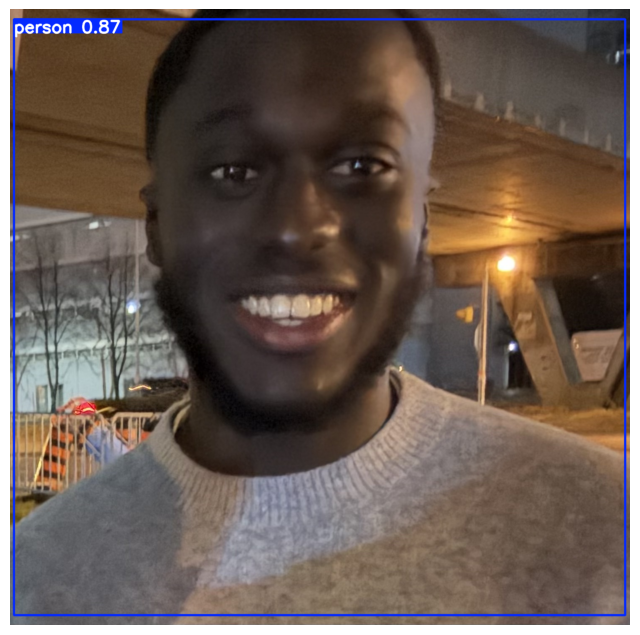

[{'box': [9.95674991607666, 24.86176109313965, 1467.1632080078125, 1445.8330078125], 'confidence': 0.867487907409668, 'class_id': 0, 'class_name': 'person'}]
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple',

In [ ]:
detections = yolo_detect("InOutVision/Dataset/Karamoko/IMG_6685.jpeg")

for det in detections:
    print(det)

### <b>3) <u>Combining in Facenet and yolo-v11</u>:

In [ ]:
def recognize_with_yolo(image_path):
    img = cv2.imread(image_path)

    # Run YOLO and show bounding boxes
    detections, raw_results = yolo_detect(image_path, show=False)

    r = raw_results[0]
    results = []

    for det in detections:
        if det["class_name"] in ["person", "face"]:
            x1, y1, x2, y2 = map(int, det["box"])
            crop = img[y1:y2, x1:x2]

            # Run FaceNet recognition on the cropped face
            cv2.imwrite("temp_face.jpg", crop)
            name, conf = recognize("temp_face.jpg")

            # Store result
            results.append({
                "detected_as": det["class_name"],
                "name": name,
                "confidence": conf,
                "bbox": det["box"]
            })

            # DRAWING ON IMAGE
            label = f"{name} ({conf*100:.1f}%)"

            font_scale = 4
            thickness = 15

            # Get text size
            (tw, th), _ = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness
            )

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)

            # Label background box
            cv2.rectangle(
                img,
                (x1, y1 - th - 20),
                (x1 + tw + 10, y1),
                (0, 255, 0),
                -1
            )

            # Thick text
            cv2.putText(
                img, label, (x1 + 5, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale, (0, 0, 0), thickness
            )

    #SHOW FINAL IMAGE
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    return results


image 1/1 /content/InOutVision/Dataset/Stanley/1000036002.jpeg: 640x448 1 person, 149.8ms
Speed: 4.1ms preprocess, 149.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 448)


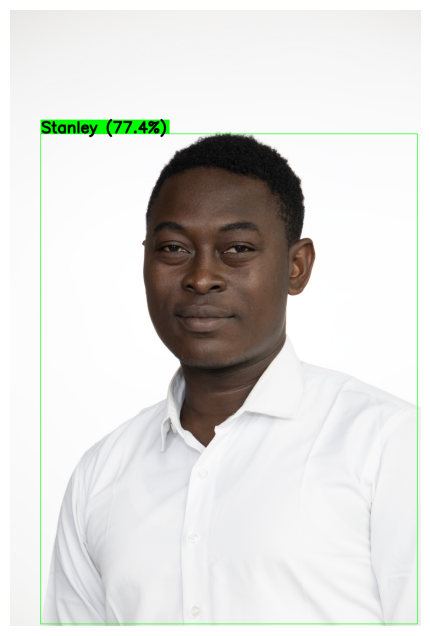

[{'detected_as': 'person',
  'name': 'Stanley',
  'confidence': 0.7743112874435175,
  'bbox': [243.52243041992188, 985.8052368164062, 3241.3720703125, 4887.375]}]

In [ ]:
rec = recognize_with_yolo("InOutVision/Dataset/Stanley/1000036002.jpeg")
rec


image 1/1 /content/InOutVision/Pictest/IMG_7353.jpeg: 640x480 1 person, 1 tie, 170.4ms
Speed: 5.1ms preprocess, 170.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


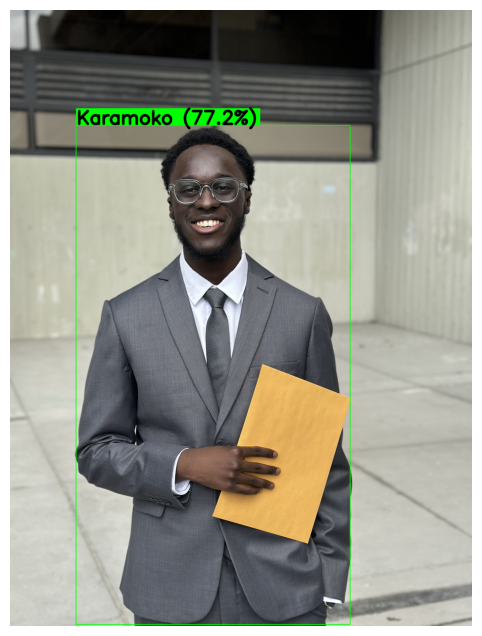

[{'detected_as': 'person',
  'name': 'Karamoko',
  'confidence': 0.7723577807944827,
  'bbox': [432.3582458496094,
   755.687744140625,
   2226.40478515625,
   4022.415283203125]}]

In [ ]:
rec2 = recognize_with_yolo("InOutVision/Pictest/IMG_7353.jpeg")
rec2


image 1/1 /content/InOutVision/Pictest/img1.jpeg: 640x480 1 person, 2 bicycles, 158.4ms
Speed: 3.9ms preprocess, 158.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 480)


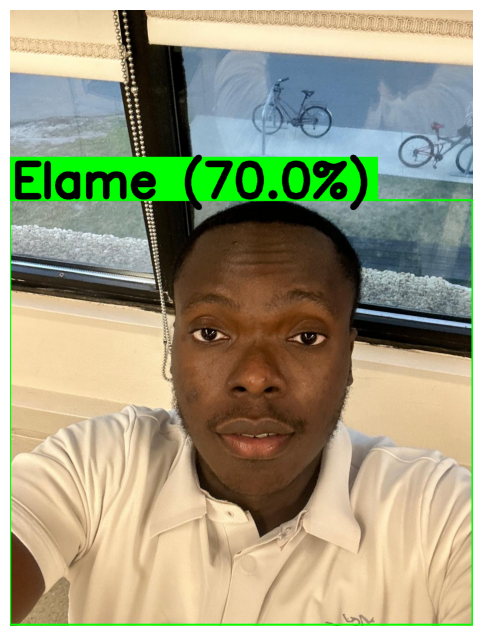

[{'detected_as': 'person',
  'name': 'Elame',
  'confidence': 0.7003328454247313,
  'bbox': [0.0, 493.8075256347656, 1198.02685546875, 1595.3975830078125]}]

In [ ]:
rec3 = recognize_with_yolo("InOutVision/Pictest/img1.jpeg")
rec3

###<b> 4) <u>Video Processing</u>:

In [ ]:
# Separating videos into frames
def extract_frames(video_path, frame_skip=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_id = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_id % frame_skip == 0:
            frames.append((frame_id, frame.copy()))

        frame_id += 1

    cap.release()
    return frames

In [ ]:
# Frame processing with state-of-art
def process_frame_for_recognition(frame):
    """Runs YOLO on frame, then sends each ROI to FaceNet."""
    # Save temporarily for YOLO
    cv2.imwrite("temp_frame.jpg", frame)

    detections, raw = yolo_detect("temp_frame.jpg", show=False)
    r = raw[0]

    results = []

    for det in detections:
        if det["class_name"] not in ["person", "face"]:
            continue

        x1, y1, x2, y2 = map(int, det["box"])
        crop = frame[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        cv2.imwrite("temp_crop.jpg", crop)

        # FaceNet identify
        name, conf = recognize("temp_crop.jpg")

        results.append({
            "name": name,
            "confidence": conf,
            "bbox": det["box"],
            "crop": crop
        })

    return results

In [ ]:
def analyze_video(video_path, frame_skip=5):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("❌ Cannot open video:", video_path)
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"🎞 Total frames: {total_frames}")

    # Store all distances for each person
    video_distances = defaultdict(list)

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_skip != 0:
            frame_idx += 1
            continue

        print(f"\nProcessing frame {frame_idx}...")

        # --- YOLO detect people ---
        results = yolo_model(frame)
        detections = results[0].boxes.data.cpu().numpy()

        # If YOLO finds no person → skip
        persons = [d for d in detections if int(d[5]) == 0]

        if len(persons) == 0:
            print("No person detected.")
            frame_idx += 1
            continue

        # Only use the biggest person box
        persons = sorted(persons, key=lambda x: (x[2]-x[0])*(x[3]-x[1]), reverse=True)
        x1, y1, x2, y2, conf, cls = persons[0]
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        crop = frame[y1:y2, x1:x2]

        # --- RetinaFace refine detection ---
        face = detect_face(crop)
        if face is None:
            print("RetinaFace could not find a face.")
            frame_idx += 1
            continue

        # --- FaceNet embedding ---
        face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face_img = Image.fromarray(face_rgb)
        face_tensor = transform(face_img).unsqueeze(0).to(device)

        with torch.no_grad():
            emb = model(face_tensor).cpu().numpy()[0]

        # --- Compare to all dataset embeddings ---
        for name, ref_emb in embeddings_dict.items():
            dist = np.linalg.norm(emb - ref_emb)
            video_distances[name].append(dist)

        frame_idx += 1

    cap.release()

    print("\n📊 Distance summary:")
    for name, dists in video_distances.items():
        if len(dists) > 0:
            print(f"- {name}: {len(dists)} samples, avg distance = {np.mean(dists):.4f}")

    # --- If no distances collected ---
    if len(video_distances) == 0:
        print("❌ No valid face detected in the entire video.")
        return None

    # --- Compute final identity ---
    final_scores = {}
    for name, dists in video_distances.items():
        if len(dists) > 0:
            final_scores[name] = np.mean(dists)

    final_identity = min(final_scores, key=final_scores.get)
    final_distance = final_scores[final_identity]

    print("\n✅ Final Decision:")
    print(f"Person: {final_identity}")
    print(f"Mean Distance: {final_distance:.4f}")

    return {
        "distances": video_distances,
        "final_identity": final_identity,
        "final_distance": final_distance
    }

#### <b> VIDEO ANALYSIS TEST:

In [ ]:
video_results = analyze_video("InOutVision/VideoTest/Video_arak.mov")
len(video_results)

🎞 Total frames: 205

Processing frame 0...

0: 448x640 (no detections), 420.2ms
Speed: 29.3ms preprocess, 420.2ms inference, 6.7ms postprocess per image at shape (1, 3, 448, 640)
No person detected.

Processing frame 5...

0: 448x640 (no detections), 282.8ms
Speed: 9.6ms preprocess, 282.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
No person detected.

Processing frame 10...

0: 448x640 (no detections), 283.6ms
Speed: 13.0ms preprocess, 283.6ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
No person detected.

Processing frame 15...

0: 448x640 (no detections), 385.7ms
Speed: 9.4ms preprocess, 385.7ms inference, 4.1ms postprocess per image at shape (1, 3, 448, 640)
No person detected.

Processing frame 20...

0: 448x640 (no detections), 248.8ms
Speed: 8.6ms preprocess, 248.8ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
No person detected.

Processing frame 25...

0: 448x640 (no detections), 288.4ms
Speed: 5.1ms preprocess,

3

In [ ]:
def show_detected_crops(results, max_show=10):
    plt.figure(figsize=(12, 12))
    for i, r in enumerate(results[:max_show]):
        img = cv2.cvtColor(cv2.imread(r["crop_path"]), cv2.COLOR_BGR2RGB)
        plt.subplot(5, 5, i+1)
        plt.imshow(img)
        plt.title(f"{r['name']} ({r['confidence']:.2f})")
        plt.axis("off")
    plt.show()

#### <b> 5)<u>Metrics</u>:

In [ ]:
import numpy as np
import random
from collections import defaultdict
from sklearn.metrics import accuracy_score

def identification_nn(embeddings, labels, gallery_per_person=1, seed=42):
    random.seed(seed)
    idx_by_label = defaultdict(list)
    for i, lab in enumerate(labels):
        idx_by_label[lab].append(i)

    gallery_idx, probe_idx = [], []
    for lab, inds in idx_by_label.items():
        inds = inds.copy()
        random.shuffle(inds)
        gallery_idx.extend(inds[:gallery_per_person])
        probe_idx.extend(inds[gallery_per_person:])

    gallery_embs = embeddings[gallery_idx]; gallery_labels = labels[gallery_idx]
    probe_embs = embeddings[probe_idx]; probe_labels = labels[probe_idx]

    preds = []
    for emb in probe_embs:
        dists = np.linalg.norm(gallery_embs - emb, axis=1)
        best = np.argmin(dists)
        preds.append(gallery_labels[best])

    acc = accuracy_score(probe_labels, preds)
    return acc, probe_labels, preds, gallery_embs, gallery_labels

acc, true_labels, preds, g_embs, g_labels = identification_nn(X, y, gallery_per_person=1)
print(f"1-NN identification accuracy (gallery=1): {acc:.4f}")


1-NN identification accuracy (gallery=1): 0.5625


Classifier accuracy on embeddings: 0.9474


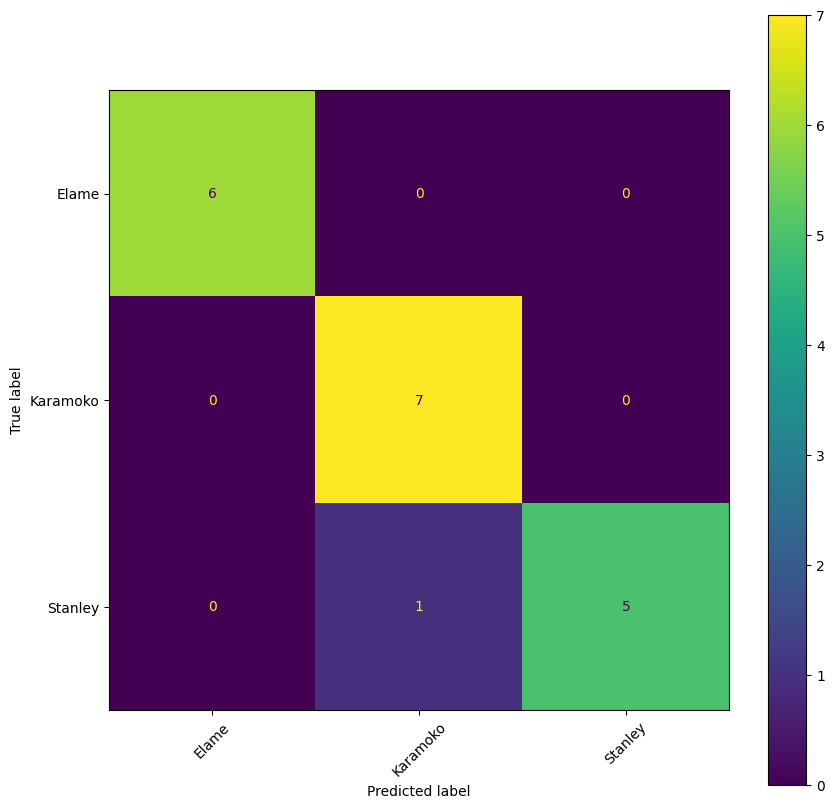

Elame: precision=1.000 recall=1.000 support=6
Karamoko: precision=0.875 recall=1.000 support=7
Stanley: precision=1.000 recall=0.833 support=6


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

# Use your clf and le
y_pred = clf.predict(X)           # predicted integer labels
y_true_int = le.transform(y)

acc_clf = accuracy_score(y_true_int, y_pred)
print(f"Classifier accuracy on embeddings: {acc_clf:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true_int, y_pred, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
disp.plot(xticks_rotation=45, ax=plt.gca())
plt.show()

# Precision/Recall per class
p, r, f, s = precision_recall_fscore_support(y_true_int, y_pred, labels=range(len(le.classes_)))
for i, name in enumerate(le.classes_):
    print(f"{name}: precision={p[i]:.3f} recall={r[i]:.3f} support={s[i]}")


AUC: 0.7855, EER (approx): 0.2915, TAR@FAR=1e-3: 0.5420


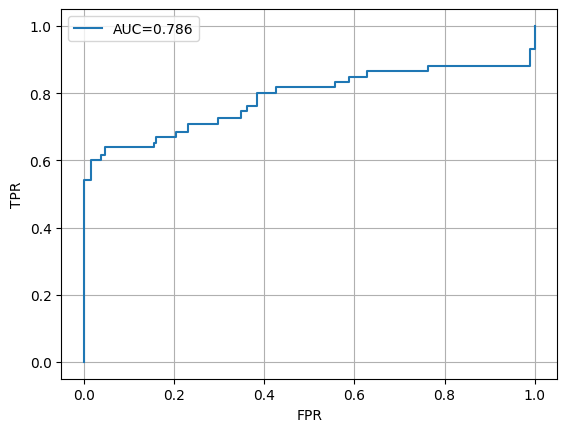

In [ ]:
from sklearn.metrics import roc_curve, auc
import math

# Build pairs (balanced pos/neg)
def make_pairs(embeddings, labels, n_pairs=2000):
    idx_by_label = {}
    for i, lab in enumerate(labels):
        idx_by_label.setdefault(lab, []).append(i)
    labels_list = [l for l in idx_by_label.keys()]
    left, right, pl = [], [], []
    import random
    for _ in range(n_pairs//2):
        lab = random.choice(labels_list)
        inds = idx_by_label[lab]
        if len(inds) < 2: continue
        a,b = random.sample(inds,2)
        left.append(embeddings[a]); right.append(embeddings[b]); pl.append(1)
    for _ in range(n_pairs//2):
        a_lab,b_lab = random.sample(labels_list,2)
        a = random.choice(idx_by_label[a_lab]); b = random.choice(idx_by_label[b_lab])
        left.append(embeddings[a]); right.append(embeddings[b]); pl.append(0)
    return np.array(left), np.array(right), np.array(pl)

left, right, pair_labels = make_pairs(X, y, n_pairs=2000)

# compute cosine similarity scores
def cosine_sim(a,b):
    return (a@b) / (np.linalg.norm(a)*np.linalg.norm(b) + 1e-10)

sims = np.array([cosine_sim(a,b) for a,b in zip(left, right)])
fpr, tpr, thr = roc_curve(pair_labels, sims)
roc_auc = auc(fpr, tpr)

# EER
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

def tar_at_far(target_far):
    idx = np.where(fpr <= target_far)[0]
    if len(idx)==0: return 0.0
    return tpr[idx[-1]]

print(f"AUC: {roc_auc:.4f}, EER (approx): {eer:.4f}, TARgFAR=1e-3: {tar_at_far(1e-3):.4f}")
# Plot ROC
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.grid(); plt.legend(); plt.show()

Intra-class samples: 51
Inter-class samples: 120


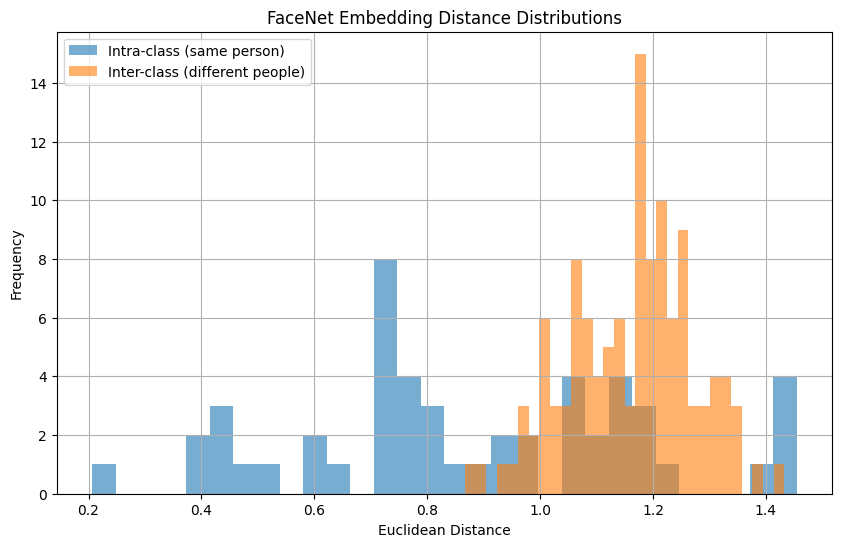

Mean Intra-class distance: 0.88133436
Mean Inter-class distance: 1.1621087
Separation ratio (inter / intra): 1.3185786


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# --------------------------------------------------
# BUILD MULTI-EMBEDDING DICT FROM IMAGES
# embeddings_dict must have: {name: [emb1, emb2, ...]}
# If your dict is single emb per person: convert to list
# --------------------------------------------------

multi_embeddings = {}

for person, emb in embeddings_dict.items():
    if isinstance(emb, list) or isinstance(emb, np.ndarray) and len(emb.shape) > 1:
        multi_embeddings[person] = emb  # already list
    else:
        multi_embeddings[person] = [emb]  # wrap as list

# --------------------------------------------------
# COMPUTE DISTANCES
# --------------------------------------------------

intra_distances = []
inter_distances = []

# Same-person distances
for person, embs in multi_embeddings.items():
    if len(embs) >= 2:
        for e1, e2 in combinations(embs, 2):
            intra_distances.append(np.linalg.norm(e1 - e2))

# Different-person distances
persons = list(multi_embeddings.keys())
for p1, p2 in combinations(persons, 2):
    for e1 in multi_embeddings[p1]:
        for e2 in multi_embeddings[p2]:
            inter_distances.append(np.linalg.norm(e1 - e2))

# Convert to numpy arrays
intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

print("Intra-class samples:", len(intra_distances))
print("Inter-class samples:", len(inter_distances))

# --------------------------------------------------
# PLOT HISTOGRAM
# --------------------------------------------------

plt.figure(figsize=(10,6))
plt.hist(intra_distances, bins=30, alpha=0.6, label="Intra-class (same person)")
plt.hist(inter_distances, bins=30, alpha=0.6, label="Inter-class (different people)")

plt.title("FaceNet Embedding Distance Distributions")
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

print("Mean Intra-class distance:", np.mean(intra_distances))
print("Mean Inter-class distance:", np.mean(inter_distances))

print("Separation ratio (inter / intra):",np.mean(inter_distances) / np.mean(intra_distances))

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def evaluate_yolo_facenet(results_list, ground_truth_name):
    """
    results_list: list of dictionaries returned by recognize_with_yolo
    ground_truth_name: the true name of the person in the image/video
    """

    if len(results_list) == 0:
        print("No faces detected.")
        return None

    predicted_names = [r['name'] for r in results_list]
    confidences = [r['confidence'] for r in results_list]

    # Binary correctness
    correct = [1 if name == ground_truth_name else 0 for name in predicted_names]
    accuracy = np.mean(correct)

    # Print basic stats
    print(f"Ground truth: {ground_truth_name}")
    print(f"Predictions: {predicted_names}")
    print(f"Confidences: {confidences}")
    print(f"Accuracy: {accuracy:.2f}")

    # If multiple classes, compute classification report
    unique_names = list(set(predicted_names + [ground_truth_name]))
    y_true = [ground_truth_name]*len(predicted_names)
    y_pred = predicted_names

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=unique_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=unique_names)
    print("\nConfusion Matrix:")
    print(cm)

    return {
        "accuracy": accuracy,
        "predictions": predicted_names,
        "confidences": confidences,
        "confusion_matrix": cm
    }


image 1/1 /content/InOutVision/Pictest/img3.jpeg: 640x288 1 person, 336.7ms
Speed: 6.8ms preprocess, 336.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 288)


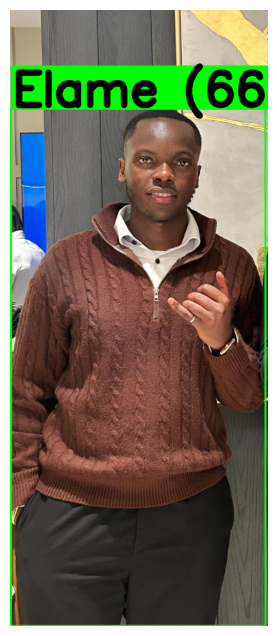

Ground truth: Elame
Predictions: ['Elame']
Confidences: [0.6692634126859381]
Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

       Elame       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1


Confusion Matrix:
[[1]]


In [ ]:
# Suppose we have an image of Elame
results = recognize_with_yolo("InOutVision/Pictest/img3.jpeg")
metrics = evaluate_yolo_facenet(results, ground_truth_name="Elame")